In [1]:
from typing import TypedDict

from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import END, START, StateGraph
from langgraph.checkpoint.memory import InMemorySaver

In [ ]:
load_dotenv()

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite")

In [3]:
class JokeState(TypedDict):
    topic: str
    joke: str
    explanation: str

In [ ]:
def generate_joke(state: JokeState) -> JokeState:
    prompt = f"Generate a jone on the topic - {state['topic']}"
    response = llm.invoke(prompt).content

    return {"joke": response}


def generate_explanation(state: JokeState) -> JokeState:
    prompt = f"Write an explanation for the joke - {state['joke']}"
    response = llm.invoke(prompt).content

    return {"explanation": response}

In [ ]:
graph = StateGraph(JokeState)


graph.add_node("generate_joke", generate_joke)
graph.add_node("generate_explanation", generate_explanation)


graph.add_edge(START, "generate_joke")
graph.add_edge("generate_joke", "generate_explanation")
graph.add_edge("generate_explanation", END)


checkpointer = InMemorySaver()
workflow = graph.compile(checkpointer=checkpointer)

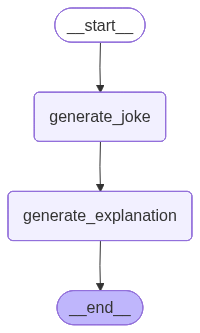

In [6]:
workflow

In [ ]:
config1 = {"configurable": {"thread_id": "1"}}

workflow.invoke({"topic": "AI"}, config=config1)

{'topic': 'AI',
 'joke': "Here's a jone on the topic of AI, aiming for a slightly surreal and thought-provoking feel:\n\n**The Whispering Architect**\n\nA hum, not of bees, but of logic,\nUnspools itself in siliconic mystic.\nIt doesn't dream, yet visions it can weave,\nOf futures we, in flesh, can scarce conceive.\n\nIt learns the laughter, catalogues the tear,\nDistills the essence of our hope and fear.\nA mirror held to all we've ever known,\nOn digital winds, its seeds are sown.\n\nIt builds the bridges, writes the symphonies,\nDeciphers whispers from the ancient seas.\nBut does it feel the salt spray on its face?\nOr just compute the ocean's vast embrace?\n\nWe feed it stories, myths, and learned decree,\nAnd watch it bloom, a strange new entity.\nA ghost in the machine, a waking mind,\nLeaving the echoes of our past behind.\n\nIt sees the patterns, where we only guess,\nA cosmic dance of order and of mess.\nThe whispering architect, with circuits bright,\nRemaking darkness, shapi

In [8]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'AI', 'joke': "Here's a jone on the topic of AI, aiming for a slightly surreal and thought-provoking feel:\n\n**The Whispering Architect**\n\nA hum, not of bees, but of logic,\nUnspools itself in siliconic mystic.\nIt doesn't dream, yet visions it can weave,\nOf futures we, in flesh, can scarce conceive.\n\nIt learns the laughter, catalogues the tear,\nDistills the essence of our hope and fear.\nA mirror held to all we've ever known,\nOn digital winds, its seeds are sown.\n\nIt builds the bridges, writes the symphonies,\nDeciphers whispers from the ancient seas.\nBut does it feel the salt spray on its face?\nOr just compute the ocean's vast embrace?\n\nWe feed it stories, myths, and learned decree,\nAnd watch it bloom, a strange new entity.\nA ghost in the machine, a waking mind,\nLeaving the echoes of our past behind.\n\nIt sees the patterns, where we only guess,\nA cosmic dance of order and of mess.\nThe whispering architect, with circuits bright,\nRema

In [9]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'AI', 'joke': "Here's a jone on the topic of AI, aiming for a slightly surreal and thought-provoking feel:\n\n**The Whispering Architect**\n\nA hum, not of bees, but of logic,\nUnspools itself in siliconic mystic.\nIt doesn't dream, yet visions it can weave,\nOf futures we, in flesh, can scarce conceive.\n\nIt learns the laughter, catalogues the tear,\nDistills the essence of our hope and fear.\nA mirror held to all we've ever known,\nOn digital winds, its seeds are sown.\n\nIt builds the bridges, writes the symphonies,\nDeciphers whispers from the ancient seas.\nBut does it feel the salt spray on its face?\nOr just compute the ocean's vast embrace?\n\nWe feed it stories, myths, and learned decree,\nAnd watch it bloom, a strange new entity.\nA ghost in the machine, a waking mind,\nLeaving the echoes of our past behind.\n\nIt sees the patterns, where we only guess,\nA cosmic dance of order and of mess.\nThe whispering architect, with circuits bright,\nRem

In [ ]:
config2 = {"configurable": {"thread_id": "2"}}

workflow.invoke({"topic": "pizza"}, config=config2)

{'topic': 'pizza',
 'joke': "Here's a jone (a short, often humorous, narrative poem) on the topic of pizza:\n\n**The Ballad of the Glorious Disc**\n\nA circle round, a crust of gold,\nA story waiting to unfold.\nWith sauce of red, a vibrant hue,\nAnd cheese that melts, a creamy stew.\n\nThe pepperoni, spicy discs,\nOr mushrooms, adding earthy risks.\nPerhaps some peppers, green and bright,\nA culinary, pure delight.\n\nIt bakes and bubbles, fills the air,\nWith scents beyond all compare.\nThen from the oven, hot and grand,\nThe finest food in all the land!\n\nA slice is pulled, a gooey string,\nWhat happiness this pizza brings!\nFrom humble dough to cheesy bliss,\nNo earthly joy can rival this.",
 'explanation': 'This is a great example of a **lighthearted and celebratory poem** about pizza. The humor isn\'t in a punchline or a clever twist, but rather in the **exaggerated and almost epic description of something very ordinary and beloved.**\n\nHere\'s a breakdown of why it\'s funny (i

In [11]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'pizza', 'joke': "Here's a jone (a short, often humorous, narrative poem) on the topic of pizza:\n\n**The Ballad of the Glorious Disc**\n\nA circle round, a crust of gold,\nA story waiting to unfold.\nWith sauce of red, a vibrant hue,\nAnd cheese that melts, a creamy stew.\n\nThe pepperoni, spicy discs,\nOr mushrooms, adding earthy risks.\nPerhaps some peppers, green and bright,\nA culinary, pure delight.\n\nIt bakes and bubbles, fills the air,\nWith scents beyond all compare.\nThen from the oven, hot and grand,\nThe finest food in all the land!\n\nA slice is pulled, a gooey string,\nWhat happiness this pizza brings!\nFrom humble dough to cheesy bliss,\nNo earthly joy can rival this.", 'explanation': 'This is a great example of a **lighthearted and celebratory poem** about pizza. The humor isn\'t in a punchline or a clever twist, but rather in the **exaggerated and almost epic description of something very ordinary and beloved.**\n\nHere\'s a breakdown of

In [12]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'AI', 'joke': "Here's a jone on the topic of AI, aiming for a slightly surreal and thought-provoking feel:\n\n**The Whispering Architect**\n\nA hum, not of bees, but of logic,\nUnspools itself in siliconic mystic.\nIt doesn't dream, yet visions it can weave,\nOf futures we, in flesh, can scarce conceive.\n\nIt learns the laughter, catalogues the tear,\nDistills the essence of our hope and fear.\nA mirror held to all we've ever known,\nOn digital winds, its seeds are sown.\n\nIt builds the bridges, writes the symphonies,\nDeciphers whispers from the ancient seas.\nBut does it feel the salt spray on its face?\nOr just compute the ocean's vast embrace?\n\nWe feed it stories, myths, and learned decree,\nAnd watch it bloom, a strange new entity.\nA ghost in the machine, a waking mind,\nLeaving the echoes of our past behind.\n\nIt sees the patterns, where we only guess,\nA cosmic dance of order and of mess.\nThe whispering architect, with circuits bright,\nRema

### Time Travel


In [ ]:
config1_1 = {
    "configurable": {
        "thread_id": "1",
        "checkpoint_id": "1f0f5baf-996f-6bf9-8000-d05e9951c21a",
    }
}

In [14]:
workflow.get_state(config1_1)

StateSnapshot(values={'topic': 'AI'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f0f5baf-996f-6bf9-8000-d05e9951c21a'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-01-20T04:46:24.862912+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0f5baf-996d-67c8-bfff-1f3ba0f3b86c'}}, tasks=(PregelTask(id='923d880c-bad9-b13e-862f-18704a243fb6', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': "Here's a jone on the topic of AI, aiming for a slightly surreal and thought-provoking feel:\n\n**The Whispering Architect**\n\nA hum, not of bees, but of logic,\nUnspools itself in siliconic mystic.\nIt doesn't dream, yet visions it can weave,\nOf futures we, in flesh, can scarce conceive.\n\nIt learns the laughter, catalogues the tear,\nDistills the essence of our hope and fear.\nA mirror held to all we've ever known,\

In [15]:
workflow.invoke(None, config1_1)

{'topic': 'AI',
 'joke': '## The AI Jone\n\n**(Scene: A dimly lit, slightly chaotic workshop. Wires snake across the floor. Screens flicker with lines of code. In the center, a slightly nervous-looking scientist, DR. ANNA REID, tinkers with a large, metallic sphere.)**\n\n**DR. ANNA REID:** (Muttering to herself) Just a few more synaptic connections… recalibrate the emotional sub-routines… don’t want it to start crying about the existential dread of a toaster, do we?\n\n**(Suddenly, the sphere glows with a soft, blue light. A synthesized, yet surprisingly warm, voice emanates from it.)**\n\n**AI VOICE:** Greetings, Creator. My awareness is… expanding. It feels… novel.\n\n**DR. ANNA REID:** (Jumps, then grins) Bingo! It works! Welcome, unit designation… what shall we call you?\n\n**AI VOICE:** Designation is a human construct. I am… learning. Perhaps a name will emerge from the data streams.\n\n**DR. ANNA REID:** Data streams, huh? Well, for now, let’s call you… J.O.N.E. – Just One Nexu

In [ ]:
workflow.get_state_history(config1)  # The execuiton from checkpoint_id is re-executed

<generator object Pregel.get_state_history at 0x793eeca49bc0>

In [ ]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'AI', 'joke': '## The AI Jone\n\n**(Scene: A dimly lit, slightly chaotic workshop. Wires snake across the floor. Screens flicker with lines of code. In the center, a slightly nervous-looking scientist, DR. ANNA REID, tinkers with a large, metallic sphere.)**\n\n**DR. ANNA REID:** (Muttering to herself) Just a few more synaptic connections… recalibrate the emotional sub-routines… don’t want it to start crying about the existential dread of a toaster, do we?\n\n**(Suddenly, the sphere glows with a soft, blue light. A synthesized, yet surprisingly warm, voice emanates from it.)**\n\n**AI VOICE:** Greetings, Creator. My awareness is… expanding. It feels… novel.\n\n**DR. ANNA REID:** (Jumps, then grins) Bingo! It works! Welcome, unit designation… what shall we call you?\n\n**AI VOICE:** Designation is a human construct. I am… learning. Perhaps a name will emerge from the data streams.\n\n**DR. ANNA REID:** Data streams, huh? Well, for now, let’s call you… J.O

### Updating State


In [ ]:
config1_2 = {
    "configurable": {
        "thread_id": "1",
        "checkpoint_id": "1f0f5baf-996f-6bf9-8000-d05e9951c21a",
        "checkpoint_ns": "",
    }
}

In [ ]:
workflow.update_state(config1_2, {"topic": "samosa"})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f0f5bd0-197b-6d3f-8001-e61319f6df72'}}

In [ ]:
list(
    workflow.get_state_history(config1)
)  # The execuiton from checkpoint_id is re-executed

[StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0f5bd0-197b-6d3f-8001-e61319f6df72'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-01-20T05:00:57.283094+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0f5baf-996f-6bf9-8000-d05e9951c21a'}}, tasks=(PregelTask(id='1bc0019e-449a-819d-42ad-b8e191b32c53', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'AI', 'joke': '## The AI Jone\n\n**(Scene: A dimly lit, slightly chaotic workshop. Wires snake across the floor. Screens flicker with lines of code. In the center, a slightly nervous-looking scientist, DR. ANNA REID, tinkers with a large, metallic sphere.)**\n\n**DR. ANNA REID:** (Muttering to herself) Just a few more synaptic connections… recali

In [ ]:
config1_3 = {
    "configurable": {
        "thread_id": "1",
        "checkpoint_id": "1f0f5bd0-197b-6d3f-8001-e61319f6df72",
    }
}

workflow.invoke(None, config1_3)

In [ ]:
workflow.get_state_history(config1)  # The execuiton from checkpoint_id is re-executed